<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCPT_Teaser.png" width=100% style="float: right;" alt="PCPT Teaser"></a>
</div>

# Unit 3: PyTorch Tensors

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>   
    <li><a href='#background_data_structures' style="color:#1B5E20;"><strong>Background:</strong> Core Data Structures</a></li>    
    <li><a href='#creation' style="color:black;">Tensor Creation</a></li>
    <li><a href='#attributes' style="color:black;">Tensor Attributes and Data Types</a></li>    
    <li><a href='#operations' style="color:black;">Tensor Operations</a></li>    
    <li><a href='#storage' style="color:black;">Tensor Storage</a></li>         
    <li><a href='#exercise_image_tensor' style="color:#006064;"><strong>Exercise 1:</strong>  Preprocessing Grayscale Image Tensors</a></li>  
    <li><a href='#exercise_tensor_properties' style="color:#006064;"><strong>Exercise 2:</strong> Exploring Tensor Shapes and Views</a></li>            
    <li><a href='#exercise_eigen_pca' style="color:#006064;"><strong>Exercise 3:</strong> Principal Directions via Eigen Decomposition</a></li>
</ul>  

<a id='learn'></a> 
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#E65100;">Overview and Learning Objectives</h2>

<p style="color:#E65100;">
This unit is dedicated to exploring PyTorch <strong>tensors</strong>, a fundamental data structure in PyTorch that closely resembles arrays and matrices. Tensors are crucial for representing data, model inputs and outputs, and neural network parameters. This unit covers various aspects of tensors, including their creation, attributes, data types, operations, and storage. The learning objectives of this unit are as follows:
</p>

<ul style="color:#E65100;">
<li>Learn how to create PyTorch tensors using functions such as <code>torch.zeros</code>, <code>torch.ones</code>, and <code>torch.rand</code>, or by converting NumPy arrays.</li>
<li>Understand important tensor attributes, including <code>shape</code>, <code>size</code>, <code>dim</code>, <code>dtype</code>, and <code>device</code>.</li>  
<li>Explore a wide range of tensor operations, including indexing, slicing, transposition, concatenation, splitting, reshaping, addition, subtraction, matrix multiplication, and reduction operations.</li> 
<li>Understand the internal storage layout of tensors, including how tensors are organized in memory and how to check for contiguity.</li>
</ul>  

<p style="color:#E65100;">
The unit includes three hands-on exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_image_tensor">Exercise 1</a>: Preprocess grayscale image tensors for a classification pipeline.</li>
<li><a href="#exercise_tensor_properties">Exercise 2</a>: Explore tensor shapes and view operations.</li>
<li><a href="#exercise_eigen_pca">Exercise 3</a>: Identify principal directions of a 2D point cloud, connecting linear algebra with data analysis.</li>
</ul>

<p style="color:#E65100;">
For further reading, see the tutorial <a href="https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html" target="_blank">Tensors</a>, which is part of the <a href="https://pytorch.org/tutorials/beginner/basics/intro.html" target="_blank">Introduction to PyTorch</a> series. 
</p>
</div>

In [1]:
# --- Core scientific stack ---
import numpy as np
import torch

# --- Custom utilities (Unit 3) ---
from libpcpt.unit03 import (
    exercise_image_tensor,
    exercise_tensor_properties,
    exercise_eigen_pca
)

# --- Vectorized figures ---
%config InlineBackend.figure_formats = ['svg']

<a id='background_data_structures'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Core Data Structures</h2>

<p style="color:#1B5E20;">
When working with data, whether in mathematics or programming, it is helpful to think in terms of structure. The more structure a data object has, the more you can do with it. Here is a simple hierarchy of core data structures, moving from the most basic to more organized forms:
</p>

<ul style="color:#1B5E20;">
  <li><strong>Scalar:</strong> A single value, like a number or boolean (e.g., <code>3.14</code>, <code>True</code>).</li>
  <li><strong>List:</strong> A simple collection of items, possibly of different types (e.g., <code>[1, "hi", 2.5]</code>).</li>
  <li><strong>Array:</strong> Like a list, but with elements of the same type and shape, enabling efficient computation.</li>
  <li><strong>Matrix:</strong> A two-dimensional array (rows and columns) used in linear algebra and data representation.</li>
  <li><strong>Tensor:</strong> A generalization of matrices to an arbitrary number of dimensions, used widely in deep learning.</li>
</ul>

<p style="color:#1B5E20;">
Each step introduces more regularity and structure, making the data easier to analyze, manipulate, and scale. Understanding this progression is especially useful in scientific computing and machine learning frameworks like <strong>PyTorch</strong>, where <code>tensor</code> objects serve as the fundamental data type.
</p>
</div>

<a id='creation'></a> 
## Tensor Creation

The core data structure in PyTorch is the [**tensor**](https://pytorch.org/docs/stable/tensors.html), a multidimensional array that holds elements of a single data type such as integers, floats, or booleans.  Tensors can be created in many ways and are designed for efficient numerical computation. To start working with tensors, you first need to import the `torch` package, which provides functions for creating, manipulating, and performing mathematical operations on tensors. The following example shows how to create a tensor from a Python list using the `torch.tensor()` function:

In [2]:
# A plain Python list
x = [1, 2, 3, 4]
print(f"Python list: x = {x}, type = {type(x)}")

# Converting the list into a PyTorch tensor
x_torch = torch.tensor(x)
print(f"PyTorch tensor: x_torch = {x_torch}, type = {type(x_torch)}")

Python list: x = [1, 2, 3, 4], type = <class 'list'>
PyTorch tensor: x_torch = tensor([1, 2, 3, 4]), type = <class 'torch.Tensor'>


PyTorch allows you to convert a **NumPy** array into a tensor using the `torch.from_numpy()` function. This conversion is efficient because it does not create a copy of the data. Instead, the NumPy array and the resulting PyTorch tensor share the same memory. As a result, any change you make to the tensor will also appear in the NumPy array. Likewise, if you modify the NumPy array, the changes will be visible in the tensor. This shared memory is helpful for performance but can lead to unexpected results if you are not careful. The example below shows how changes to one object affect the other:


In [3]:
# Create a NumPy array
x_np = np.array([1, 2, 3, 4])
print(f"x_np = {x_np}, type = {type(x_np)}")

# Convert the NumPy array to a PyTorch tensor
x_torch = torch.from_numpy(x_np)
print(f"x_torch = {x_torch}, type = {type(x_torch)}")

# Modify the tensor and the NumPy array
x_torch[0] = 10
x_np[1] = 20

# Show how changes affect both objects
print(f"x_np = {x_np}")
print(f"x_torch = {x_torch}")

x_np = [1 2 3 4], type = <class 'numpy.ndarray'>
x_torch = tensor([1, 2, 3, 4]), type = <class 'torch.Tensor'>
x_np = [10 20  3  4]
x_torch = tensor([10, 20,  3,  4])


PyTorch also offers a variety of convenient functions to create tensors in different ways. The following examples illustrate some commonly used methods:

In [4]:
# Set a fixed random seed for reproducibility
torch.manual_seed(42)

# Create tensors from shape
shape = (3,)   # note the comma: (3,) is a tuple, not an integer
print(f"Zeros Tensor: {torch.zeros(shape)}")
print(f"Ones Tensor (float): {torch.ones(shape)}")
print(f"Ones Tensor (int): {torch.ones(shape, dtype=int)}")
print(f"Random Tensor: {torch.rand(shape)}")

# Create tensors based on an existing tensor x
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(f"Ones Tensor:\n{torch.ones_like(x)}")

# Adjust print precision and create a random tensor like x
torch.set_printoptions(precision=2)
print(f"Random Tensor (float, 2 decimals):\n{torch.rand_like(x, dtype=torch.float)}")

# Reset print precision to default (4 decimals)
torch.set_printoptions(precision=4)

Zeros Tensor: tensor([0., 0., 0.])
Ones Tensor (float): tensor([1., 1., 1.])
Ones Tensor (int): tensor([1, 1, 1])
Random Tensor: tensor([0.8823, 0.9150, 0.3829])
Ones Tensor:
tensor([[1, 1, 1],
        [1, 1, 1]])
Random Tensor (float, 2 decimals):
tensor([[0.96, 0.39, 0.60],
        [0.26, 0.79, 0.94]])


<a id='attributes'></a> 
## Tensor Attributes and Data Types

A PyTorch tensor has several **attributes** and **methods** that describe its structure and how it is stored in memory. These are important for inspecting, debugging, and understanding your data.

* `shape`: Describes the size of the tensor along each dimension. It returns an object of type `torch.Size`, which behaves like a tuple of integers. For example, a tensor with shape `(3, 4, 5)` has 3 blocks, 4 rows, and 5 columns.

* `size()`: Returns the same information as `shape`. Both `x.shape` and `x.size()` give `torch.Size([3, 4, 5])`, which represents the shape of the tensor. The difference is that `shape` is an **attribute** (read directly), while `size()` is a **method** (called like a function).

* `dim()`: Returns the number of dimensions (or axes) of the tensor. For example, a tensor with shape `(3, 4, 5)` has `x.dim() == 3`.

* `dtype`: Shows the data type of the tensor’s elements, such as `torch.float32` or `torch.int64`.

* `device`: Tells you where the tensor's data is stored, for example on the CPU or on a GPU.

* `item()`: Converts a tensor that contains only one element into a regular Python number. For example, `torch.tensor(3.5).item()` returns the float value `3.5`.

In summary, an **attribute** is information that the tensor already knows about itself, which you can simply **ask for** without using parentheses, for example `x.shape` or `x.dtype`. A **method**, in contrast, is something the tensor can **do**; it acts like a built-in function that performs an action or returns a result. Because it **does** something, you need to call it with parentheses, such as `x.size()` or `x.item()`. Here are some concrete examples:

In [5]:
# Create a 3D tensor filled with ones (3 blocks, 4 rows, 5 columns)
x = torch.ones(3, 4, 5)

print("Tensor shape:", x.shape)              # torch.Size([3, 4, 5])
print("Tensor size:", x.size())              # same as shape
print("Size in 2nd dimension:", x.size(1))   # 4
print("Number of dimensions:", x.dim())      # 3 (3D tensor)
print("Data type:", x.dtype)                 # torch.float32
print("Device:", x.device)                   # cpu or cuda
print()

# Access a single element
y = x[0, 0, 0]  # still a tensor, not a Python number
print("Single element tensor:", y)           # tensor(1.)
print("PyTorch data type:", y.dtype)         # torch.float32
print("As Python number:", y.item())         # 1.0
print("Python data type:", type(y.item()))   # <class 'float'>

Tensor shape: torch.Size([3, 4, 5])
Tensor size: torch.Size([3, 4, 5])
Size in 2nd dimension: 4
Number of dimensions: 3
Data type: torch.float32
Device: cpu

Single element tensor: tensor(1.)
PyTorch data type: torch.float32
As Python number: 1.0
Python data type: <class 'float'>


<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> The usage of the concept of <strong>dimension</strong> can be quite confusing at times. For instance, let us consider a real-valued tensor <code>x</code> with a shape of <code>(3,4,5)</code>. In mathematical terms, one might describe such a tensor as residing in a 60-dimensional vector space, denoted as $\mathbb{R}^{3\times 4 \times 5}$. However, when talking about the dimensions of a PyTorch tensor, as indicated by <code>x.dim()</code> (which is three in our example), we are actually referring to what is commonly known as <strong>axes</strong>. In this context, <code>x.size(dim=1)</code> provides the size (number of elements) in the second dimension of <code>x</code>. To add to the confusion, the <code>size</code> attribute returns the number of elements for a <strong>NumPy array</strong>, while this count is given by the <code>numel</code> attribute for a <strong>PyTorch tensor</strong>. This terminology can indeed lead to confusion, as it depends on the context and the specific framework being used.
</p>

<style>
/* Force left-aligned tables in classic HTML export */
table, th, td {
    text-align: left !important;
}
</style>

<table style="width:80%; border-collapse: collapse; margin-top: 10px; table-layout: fixed;">
    <colgroup>
      <col style="width:40%; text-align:left">
      <col style="width:30%; text-align:left">
      <col style="width:30%; text-align:left">  
    </colgroup>
    <thead>
      <tr style="background-color: #e3e3e3; text-align: left;">
        <th style="border: 1px solid #ccc; padding: 6px;">Operation</th>
        <th style="border: 1px solid #ccc; padding: 6px;">NumPy</th>
        <th style="border: 1px solid #ccc; padding: 6px;">PyTorch</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background-color: white; transition: none;">
        <td style="border: 1px solid #ccc; padding: 6px;">Get shape</td>
        <td style="border: 1px solid #ccc; padding: 6px;"><code>x_np.shape</code></td>
        <td style="border: 1px solid #ccc; padding: 6px;"><code>x_torch.size()</code></td>
      </tr>
      <tr style="background-color: white; transition: none;">
        <td style="border: 1px solid #ccc; padding: 6px;">Total number of elements</td>
        <td style="border: 1px solid #ccc; padding: 6px;"><code>x_np.size</code></td>
        <td style="border: 1px solid #ccc; padding: 6px;"><code>x_torch.numel()</code></td>
      </tr>
      <tr style="background-color: white; transition: none;">
        <td style="border: 1px solid #ccc; padding: 6px;">Size of specific dimension</td>
        <td style="border: 1px solid #ccc; padding: 6px;"><code>x_np.shape[1]</code></td>
        <td style="border: 1px solid #ccc; padding: 6px;"><code>x_torch.size(1)</code></td>
      </tr>
    </tbody>
  </table>
</div>

The following again shows how NumPy and PyTorch report a tensor's shape and total number of elements.

In [6]:
x_np = np.ones((3,4,5))
print("x_np.size: ", x_np.size)             # NumPy: total number of elements

x_torch = torch.ones((3,4,5))
print("x_torch.size():", x_torch.size())    # PyTorch: shape of the tensor
print("x_torch.numel():", x_torch.numel())  # PyTorch: total number of elements

x_np.size:  60
x_torch.size(): torch.Size([3, 4, 5])
x_torch.numel(): 60


### Scalars vs. 1D Tensors

Tensors can represent data of different dimensionalities. Even a single number can be stored as a tensor, but its structure and how you access its value depend on whether it is a **scalar** or a **1D tensor**. A scalar tensor holds one value and has no dimensions (`0D`), while a 1D tensor (vector) has one dimension, even if it contains only one element. For example, `torch.tensor(2)` creates a scalar tensor with shape `torch.Size([])` whose value can be extracted with `.item()`. In contrast, `torch.tensor([2])` or `torch.tensor((2,))` creates a one-dimensional tensor with shape `torch.Size([1])`, which you can convert to a Python list using `.tolist()`. The following code illustrates these differences in shape and value access:

In [7]:
# Case 1: Scalar tensor (0D)
x1 = torch.tensor(2)
print("x1 =", x1)                   # tensor(2)
print("x1.shape:", x1.shape)        # torch.Size([])
print("x1.item():", x1.item())      # 2 as a regular Python number
print()

# Case 2: 1D tensor from a list
x2 = torch.tensor([2])
print("x2 =", x2)                   # tensor([2])
print("x2.shape:", x2.shape)        # torch.Size([1])
# print("x2.item():", x2.item())    # would cause an error (not a scalar)
print("x2.tolist():", x2.tolist())  # [2] as a Python list
print()

# Case 3: 1D tensor from a tuple
x3 = torch.tensor((2,))
print("x3 =", x3)                   # tensor([2])
print("x3.shape:", x3.shape)        # torch.Size([1])
print("x3.tolist():", x3.tolist())  # [2] as a Python list

x1 = tensor(2)
x1.shape: torch.Size([])
x1.item(): 2

x2 = tensor([2])
x2.shape: torch.Size([1])
x2.tolist(): [2]

x3 = tensor([2])
x3.shape: torch.Size([1])
x3.tolist(): [2]


### Data Types and Conversion

Let us take a closer look at the `dtype` attribute. PyTorch supports [a range of data types](https://pytorch.org/docs/stable/tensor_attributes.html) for representing **integers**, **floating-point numbers**, and **boolean values**. These data types determine how the values in a tensor are stored in memory. The most commonly used types are:

* `torch.float32` or `torch.float`: The default type for real (decimal) numbers.  
* `torch.int64` or `torch.long`: The default type for integers.

Here are some examples that show how PyTorch chooses or sets the data type:

In [8]:
print("Data type:", torch.tensor([1, 2, 3]).dtype)                    # torch.int64
print("Data type:", torch.tensor([1, 2, 3], dtype=torch.float).dtype) # torch.float32
print("Data type:", torch.tensor([1, 2, 3], dtype=torch.int32).dtype) # torch.int32
print("Data type:", torch.tensor([1., 2, 3]).dtype)                   # torch.float32
print("Data type:", torch.ones(1, 2).dtype)                           # torch.float32

Data type: torch.int64
Data type: torch.float32
Data type: torch.int32
Data type: torch.float32
Data type: torch.float32


In PyTorch, **casting** means converting a tensor from one data type to another (for example, from integers to floats). This can be done in several ways. Two common methods are using `.type(dtype)` and `.to(dtype)`, both returning a tensor with the specified data type.

In [9]:
# Create a float tensor (default dtype = float32)
x = torch.tensor([1.234, 2.1, 3.3])
print("x  =", x)
print("Data type of x:", x.dtype)  # torch.float32

# Cast to int32 using .type()  (truncates decimals)
y1 = x.type(torch.int32)
print("\ny1 =", y1)
print("Data type of y1:", y1.dtype)  # torch.int32

# Cast to int32 using .to()  (same result as above)
y2 = x.to(torch.int32)
print("\ny2 =", y2)
print("Data type of y2:", y2.dtype)  # torch.int32

x  = tensor([1.2340, 2.1000, 3.3000])
Data type of x: torch.float32

y1 = tensor([1, 2, 3], dtype=torch.int32)
Data type of y1: torch.int32

y2 = tensor([1, 2, 3], dtype=torch.int32)
Data type of y2: torch.int32


<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong>
The default data types employed for PyTorch tensors  (<code>torch.float32</code>, <code>torch.int64</code>) differ from the default data types used in NumPy arrays (<code>float64</code>, <code>int64</code>). When converting between NumPy arrays and PyTorch tensors, the data type is preserved, and they may even share the same underlying memory when stored on the CPU. This can lead to inconsistencies and confusion if data types are not explicitly specified.
</p>
</div>

In PyTorch, you can convert between **NumPy arrays** and **PyTorch tensors** using:

* `torch.from_numpy(x)`: Creates a tensor that shares memory with the NumPy array `x`.
* `.to(dtype=...)`: Converts the tensor to a different data type. If old and new data types are identical, memory is still shared.

The code below demonstrates how PyTorch handles data types during conversion, and how the `.to()` method is used to explicitly change a tensor's data type.

In [10]:
# Convert NumPy array to PyTorch tensor (shares memory)
x_np = np.array([1., 2., 3.])
x_torch = torch.from_numpy(x_np)
print("Data type for x_np:", x_np.dtype)
print("Data type for x_torch:", x_torch.dtype)

# Convert PyTorch tensor back to NumPy array (shares memory)
y_torch = torch.tensor([1., 2., 3.])
y_np = y_torch.numpy()
print("\nData type for y_torch:", y_torch.dtype)
print("Data type for y_np:", y_np.dtype)

# Cast the NumPy-based tensor to a different dtype (does NOT share memory)
a_torch = torch.from_numpy(x_np).to(dtype=torch.float32)
print("\nData type for a_torch:", a_torch.dtype)
a_torch[2] = 5
print("Modified tensor a_torch =", a_torch)
print("Original array x_np =", x_np)

# Cast the NumPy-based tensor to the same dtype (DOES share memory)
b_torch = torch.from_numpy(x_np).to(dtype=torch.float64)
print("\nData type for b_torch:", b_torch.dtype)
b_torch[2] = 5
print("Modified tensor b_torch =", b_torch)
print("Original array x_np =", x_np)

Data type for x_np: float64
Data type for x_torch: torch.float64

Data type for y_torch: torch.float32
Data type for y_np: float32

Data type for a_torch: torch.float32
Modified tensor a_torch = tensor([1., 2., 5.])
Original array x_np = [1. 2. 3.]

Data type for b_torch: torch.float64
Modified tensor b_torch = tensor([1., 2., 5.], dtype=torch.float64)
Original array x_np = [1. 2. 5.]


### Device

Each PyTorch tensor has a `.device` attribute that tells you where its data is stored, either on the **CPU** (default) or on a **GPU** (called `cuda` in PyTorch). Although the PCPT notebooks use CPU-only computations, it is still helpful to understand how device placement works. The `.to()` method can be used not only to change a tensor's data type but also to move it between devices. You can, for example, move a tensor to the GPU (if available) and convert its data type in a single step. The following code shows how to check a tensor's device and move it if needed:

In [11]:
# Create a tensor on the default device (CPU)
x = torch.tensor([1, 2, 3])
print(f"Original tensor: device = {x.device}, dtype = {x.dtype}")

# Select device: use 'cuda' if available, otherwise stay on 'cpu'
device = "cuda" if torch.cuda.is_available() else "cpu"

# Move tensor to the selected device and convert its data type
z = x.to(dtype=torch.float64, device=device)
print(f"Converted tensor: device = {z.device}, dtype = {z.dtype}")

Original tensor: device = cpu, dtype = torch.int64
Converted tensor: device = cpu, dtype = torch.float64


**Note:** In this example, both tensors stay on the CPU because a GPU is not available.  Even if your computer has a GPU, PyTorch will only use it if you have installed a GPU-compatible version of PyTorch.

<a id='operations'></a>
## Tensor Operations

PyTorch tensors support a rich set of operations, which can be grouped into several categories:

- **Elementwise operations**: Perform calculations on each element, e.g., `torch.add()`, `torch.mul()`, `torch.div()`
- **Linear algebra operations**: Handle matrix and vector math, e.g., `torch.matmul()`, `torch.linalg.det()`
- **Reduction operations**: Reduce tensors to a single value or lower dimension, e.g., `torch.sum()`, `torch.max()`, `torch.argmax()`
- **Indexing and reshaping operations**: Change the shape or combine tensors, e.g., `torch.view()`, `torch.reshape()`, `torch.cat()`

For a full list of supported operations, see the [PyTorch documentation](https://pytorch.org/docs/stable/torch.html). Below, we show common examples of these operations in practice.

### Indexing, Slicing, and Splitting

In PyTorch, **indexing** and **slicing** allow you to access specific elements or subsets of a tensor, much like in NumPy. These operations are useful for examining, modifying, or extracting parts of your data. 

In [12]:
# Create a 2D tensor of shape (2, 3)
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print("Tensor x:\n", x)
print("Shape of x:", x.shape)          # torch.Size([2, 3])

# Indexing and slicing examples
print("\nFirst row:", x[0])            # tensor([1, 2, 3])
print("Shape:", x[0].shape)            # torch.Size([3])

print("\nLast column:", x[:, -1])      # tensor([3, 6])
print("Shape:", x[:, -1].shape)        # torch.Size([2])

print("\nElement x[0, 0]:", x[0, 0])   # tensor(1)
print("Shape:", x[0, 0].shape)         # torch.Size([]) (scalar tensor)


Tensor x:
 tensor([[1, 2, 3],
        [4, 5, 6]])
Shape of x: torch.Size([2, 3])

First row: tensor([1, 2, 3])
Shape: torch.Size([3])

Last column: tensor([3, 6])
Shape: torch.Size([2])

Element x[0, 0]: tensor(1)
Shape: torch.Size([])


**Splitting** allows you to divide a tensor into smaller parts along a chosen dimension. This is useful when preparing mini-batches for training, organizing data, or processing large tensors in smaller sections.

In [13]:
# Create a 2D tensor of shape (2, 3)
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print("Tensor x:\n", x)
print("Shape of x:", x.shape)

# Split the tensor into chunks of size 1 along dimension 0 (rows)
chunk_size = 1
y_rows = x.split(chunk_size, dim=0)     # Tuple of 2 tensors, each with shape (1, 3)
print("\nSplit along dim=0 (rows):")
print("First chunk:\n", y_rows[0])
print("Shape of first chunk:", y_rows[0].shape) 

# Split the tensor into chunks of size 1 along dimension 1 (columns)
y_cols = x.split(chunk_size, dim=1)     # Tuple of 3 tensors, each with shape (2, 1)
print("\nSplit along dim=1 (columns):")
print("First chunk:\n", y_cols[0])
print("Shape of first chunk:", y_cols[0].shape)

Tensor x:
 tensor([[1, 2, 3],
        [4, 5, 6]])
Shape of x: torch.Size([2, 3])

Split along dim=0 (rows):
First chunk:
 tensor([[1, 2, 3]])
Shape of first chunk: torch.Size([1, 3])

Split along dim=1 (columns):
First chunk:
 tensor([[1],
        [4]])
Shape of first chunk: torch.Size([2, 1])


### Reshaping

Reshaping means changing the dimensions of a tensor without altering its data. This is useful when preparing data for neural networks, where different layers often expect inputs in specific shapes. The number of elements in the tensor must remain the same before and after reshaping. In PyTorch, two common methods are used for reshaping:

* `view()` changes the shape **without copying** the data. It returns a new tensor that shares the same storage.
* `reshape()` also returns a reshaped tensor, but it **may copy** the data if needed (e.g., if the original tensor is not stored contiguously). More details are provided in the [storage section](#storage).

The following example demonstrates the difference between `view()` and `reshape()`:

In [14]:
# Create a 2D tensor of shape (3, 2)
x = torch.tensor([[1, 2], [3, 4], [5, 6]])
print("Original tensor x:\n", x)

# Reshape using view() and reshape()
y = x.view(2, 3)   # Shares memory with x
z = x.reshape(2, 3)  # May or may not share memory
print("\nAfter reshaping:")
print("y:", y)
print("z:", z)

# Modify the original tensor
x[1, 0] = 30
print("\nAfter modifying x[1, 0] = 30:")
print("y:", y)   # Reflects the change if memory is shared
print("z:", z)   # May or may not reflect the change


Original tensor x:
 tensor([[1, 2],
        [3, 4],
        [5, 6]])

After reshaping:
y: tensor([[1, 2, 3],
        [4, 5, 6]])
z: tensor([[1, 2, 3],
        [4, 5, 6]])

After modifying x[1, 0] = 30:
y: tensor([[ 1,  2, 30],
        [ 4,  5,  6]])
z: tensor([[ 1,  2, 30],
        [ 4,  5,  6]])


### Adding and Removing Dimensions

In PyTorch, tensors often need to be reshaped by adding or removing dimensions&mdash;especially when preparing data to fit certain functions or operations.

* `squeeze()` removes dimensions of size 1 from the tensor. This is useful for simplifying shapes without changing the underlying data.
* `unsqueeze(dim)` inserts a dimension of size 1 at the specified position. This is often needed to match expected input shapes in neural network layers.
* Alternatively, adding new dimensions can be done using indexing with `None` (equivalent to `unsqueeze`).

These operations return **views** of the original tensor, meaning they do not copy data but reuse the existing memory layout. Changes to the original tensor will be reflected in the reshaped views. The example below demonstrates these behaviors:

In [15]:
x = torch.zeros([2, 1, 1, 4])
print("Shape of x:", x.shape)

# Remove size-1 dimensions
y = x.squeeze()
print("Shape of y:", y.shape)

# Add a new dimension at the front
z = y.unsqueeze(0)
print("Shape of z:", z.shape)

# Add dimensions using None (alternative to unsqueeze)
z2 = y[None, :, :, None]
print("Shape of z2:", z2.shape)

# Modify original tensor and see the effect on views
x[0, 0, 0, 0] = 1
print("Tensor z after modifying x:\n", z)

Shape of x: torch.Size([2, 1, 1, 4])
Shape of y: torch.Size([2, 4])
Shape of z: torch.Size([1, 2, 4])
Shape of z2: torch.Size([1, 2, 4, 1])
Tensor z after modifying x:
 tensor([[[1., 0., 0., 0.],
         [0., 0., 0., 0.]]])


### Transposition

Reordering tensor dimensions is a common operation in PyTorch, especially when preparing data for neural networks. The simplest case is **transposition**, which swaps or reverses the order of a tensor's axes. In PyTorch, the shorthand `.T` is often used: for **2D tensors**, it performs a matrix transpose by swapping rows and columns (equivalent to `x.transpose(0, 1)`); for **higher-dimensional tensors**, it reverses the order of all dimensions (for example, `(1, 2, 3, 4)` becomes `(4, 3, 2, 1)`); and for **1D or scalar tensors**, it has no effect. The more general method `transpose(dim1, dim2)` explicitly swaps any two dimensions, which is particularly useful when working with tensors that have three or more axes. Here are some examples:

In [16]:
# Create a 2D tensor of shape (3, 2)
x = torch.tensor([[1, 2],
                  [3, 4],
                  [5, 6]])
print("Original tensor x:\n", x)

# Transpose by explicitly swapping axes (rows <-> columns)
y1 = x.transpose(0, 1)
print("\nTranspose using transpose(0, 1):\n", y1)

# Transpose using shorthand notation (.T) — same result as above
y2 = x.T
print("\nTranspose using .T:\n", y2)

Original tensor x:
 tensor([[1, 2],
        [3, 4],
        [5, 6]])

Transpose using transpose(0, 1):
 tensor([[1, 3, 5],
        [2, 4, 6]])

Transpose using .T:
 tensor([[1, 3, 5],
        [2, 4, 6]])


### Permutation

While transposition swaps only two axes, **permutation** allows you to reorder **all** dimensions of a tensor in any desired way. The function `permute()` takes a sequence that defines the new order of dimensions, where each axis must appear exactly once. It returns a **view** of the original tensor, meaning no data is copied. Permutation is particularly useful when changing data layouts, for example, converting between channel-first `(C, H, W)` and channel-last `(H, W, C)` formats in image processing. Here are some examples:

In [17]:
# Create a 3D tensor of shape (2, 3, 4, 5)
x = torch.zeros(2, 3, 4, 5)
print("Original shape of x:", x.shape)

# Permute the dimensions
y = x.permute(2, 3, 1, 0)
print("Permuted shape of y:", y.shape)

Original shape of x: torch.Size([2, 3, 4, 5])
Permuted shape of y: torch.Size([4, 5, 3, 2])


### Concatenation

Sometimes it is useful to join multiple tensors into a single larger one. **Concatenation** combines tensors along an **existing dimension** using `torch.cat()`. All tensors must have the same shape in every dimension **except** the one you concatenate along, where their sizes may differ. This operation is commonly used to extend a tensor **vertically** (by adding rows) or **horizontally** (by adding columns).

In [18]:
# Create two 2D tensors with compatible shapes
x1 = torch.tensor([[1, 2, 3, 4],
                   [5, 6, 7, 8]])              # shape: (2, 4)
x2 = torch.tensor([[9, 10, 11, 12]])           # shape: (1, 4)

print("Tensor x1:\n", x1)
print("Tensor x2:\n", x2)

# Concatenate vertically (along rows, dim=0)
y_rows = torch.cat([x1, x2], dim=0)            # join along rows
print("\nConcatenation along rows (dim=0):\n", y_rows)
print("Shape:", y_rows.shape)                  # shape: (3, 4)

# Concatenate horizontally (along columns, dim=1)
# First reshape to match row count
x2_reshaped = x2.reshape(2, 2)                 # shape: (2, 2)
y_cols = torch.cat([x1, x2_reshaped], dim=1)   # join along columns
print("\nConcatenation along columns (dim=1):\n", y_cols)
print("Shape:", y_cols.shape)                  # shape: (2, 6)

Tensor x1:
 tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])
Tensor x2:
 tensor([[ 9, 10, 11, 12]])

Concatenation along rows (dim=0):
 tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])
Shape: torch.Size([3, 4])

Concatenation along columns (dim=1):
 tensor([[ 1,  2,  3,  4,  9, 10],
        [ 5,  6,  7,  8, 11, 12]])
Shape: torch.Size([2, 6])


### Stacking

Another way to combine tensors is **stacking**, which joins tensors along a **new dimension** using `torch.stack()`. Unlike concatenation, where tensors are joined along an existing axis, stacking adds an entirely new one. All tensors must have **exactly the same shape**, since they are aligned along this new dimension. This operation is commonly used to build higher-dimensional tensors, for example when combining several 2D tensors into a single 3D batch.

In [19]:
# Create two simple 1D tensors
x1 = torch.tensor([1, 2, 3])                   # shape: (3,)
x2 = torch.tensor([4, 5, 6])                   # shape: (3,)

# Stack along a new dimension
y0 = torch.stack([x1, x2], dim=0)              # adds new dimension at the front
print("Stacking along new dim=0:\n", y0)
print("Shape:", y0.shape)                      # shape: (2, 3)

y1 = torch.stack([x1, x2], dim=1)              # adds new dimension at the end
print("Stacking along new dim=1:\n", y1)
print("Shape:", y1.shape)                      # shape: (3, 2)


Stacking along new dim=0:
 tensor([[1, 2, 3],
        [4, 5, 6]])
Shape: torch.Size([2, 3])
Stacking along new dim=1:
 tensor([[1, 4],
        [2, 5],
        [3, 6]])
Shape: torch.Size([3, 2])


### Elementwise Matrix Operations

Elementwise matrix operations apply a specific operation to corresponding elements of two or more tensors. These operations are performed independently on each pair of elements and are fundamental in tensor-based computation. Common examples include:

* Addition
* Subtraction
* Elementwise (Hadamard) multiplication
* Division
* Exponentiation
* Logarithm
* Elementwise comparison (e.g., `<`, `==`)

The following example demonstrates several of these operations:

In [20]:
x = torch.tensor([[0, 1, 2]], dtype=torch.float32)
y = torch.ones((1, 3), dtype=torch.float32) * 2

print("Tensor x:", x)
print("Tensor y:", y)
print("\nAddition:", x + y)
print("Addition (torch.add):", torch.add(x, y))
print("Multiplication:", x * y)
print("Multiplication (torch.mul):", torch.mul(x, y))
print("Division:", x / y)
print("Exponentiation (torch.exp):", torch.exp(x))
print("Logarithm (torch.log):", torch.log(x))        # Note: log(0) is -inf 
print("Comparison x < y:", x < y)
print("Comparison x == y:", x == y)

Tensor x: tensor([[0., 1., 2.]])
Tensor y: tensor([[2., 2., 2.]])



Addition: tensor([[2., 3., 4.]])
Addition (torch.add): tensor([[2., 3., 4.]])
Multiplication: tensor([[0., 2., 4.]])
Multiplication (torch.mul): tensor([[0., 2., 4.]])
Division: tensor([[0.0000, 0.5000, 1.0000]])


Exponentiation (torch.exp): tensor([[1.0000, 2.7183, 7.3891]])
Logarithm (torch.log): tensor([[  -inf, 0.0000, 0.6931]])


Comparison x < y: tensor([[ True,  True, False]])
Comparison x == y: tensor([[False, False,  True]])


### Matrix and Linear Algebra Operations

Multiplying matrices is a key part of many machine learning and deep learning tasks. PyTorch gives you several ways to do this:

- `torch.mm()` works for **two 2D matrices**, as defined in linear algebra.
- `torch.matmul()` is more **flexible**. It can handle not only 2D matrices but also more complex situations where the input tensors have more than two dimensions. It also lets you mix shapes in a smart way so you don't always need to reshape them manually.
- `@` is just a **shortcut** for writing `torch.matmul()`.
- `torch.einsum()` is the **most powerful** and expressive option. It uses **Einstein summation notation**, allowing you to define complex tensor operations with custom index patterns. You can use it not only for matrix multiplication but also for computing traces, outer products, transpositions, or reductions over specific dimensions.

In short, while `torch.mm()` works in simple cases, `torch.matmul()` is more powerful and covers a wider range of use cases&mdash;especially when working with batches of data or higher-dimensional tensors. An even more versatile function is `torch.einsum()`, which can express almost any tensor operation by explicitly specifying how dimensions interact.

In [21]:
x = torch.ones((1, 3), dtype=torch.float32)
y = torch.tensor([[1, 2],
                  [3, 4],
                  [5, 6]], dtype=torch.float32)

print("Matrix product using torch.mm:", torch.mm(x, y))
print("Matrix product using torch.matmul:", torch.matmul(x, y))
print("Matrix product using @ operator:", x @ y)
print("Matrix product using torch.einsum:", torch.einsum("ij,jk->ik", x, y))

Matrix product using torch.mm: tensor([[ 9., 12.]])
Matrix product using torch.matmul: tensor([[ 9., 12.]])
Matrix product using @ operator: tensor([[ 9., 12.]])
Matrix product using torch.einsum: tensor([[ 9., 12.]])


For square matrices, PyTorch provides efficient tools to compute key linear algebra operations:

* **Determinant**: A scalar that indicates properties like invertibility.
* **Inverse**: A matrix that yields the identity when multiplied by the original (exists only for non-singular matrices).
* **Eigenvalue decomposition**: Factorizes a matrix into eigenvalues and eigenvectors, useful in analysis and dimensionality reduction.

The example below shows how to compute these quantities and how to verify the eigenvalue equation.

In [22]:
# Define a square matrix
x = torch.tensor([[2, 1],
                  [1, 2]], dtype=torch.float32)

# Compute the determinant
print("Determinant:", torch.det(x))

# Compute the inverse
print("Inverse:\n", torch.inverse(x))

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = torch.linalg.eig(x)

# Take only the real parts (matrix is symmetric, so imaginary parts are zero)
eigvals = eigvals.real
eigvecs = eigvecs.real

print("Eigenvalues:", eigvals)
print("Eigenvectors (columns):\n", eigvecs)

# Verify the eigenvalue equation for the first eigenpair
v1 = eigvecs[:, 0]     # first eigenvector (column 0)
lambda1 = eigvals[0]   # corresponding eigenvalue

print("\nVerification for first eigenpair:")
print("x @ v1 =", x @ v1)          # matrix-vector product
print("lambda1 * v1 =", lambda1 * v1)  # scaled eigenvector

Determinant: tensor(3.)
Inverse:
 tensor([[ 0.6667, -0.3333],
        [-0.3333,  0.6667]])


Eigenvalues: tensor([3., 1.])
Eigenvectors (columns):
 tensor([[ 0.7071, -0.7071],
        [ 0.7071,  0.7071]])

Verification for first eigenpair:
x @ v1 = tensor([2.1213, 2.1213])
lambda1 * v1 = tensor([2.1213, 2.1213])


**Note**: In PyTorch, `torch.linalg.eig` returns complex outputs in general; the **columns** of the returned matrix are the eigenvectors, and the matching eigenvalues are in the same order. For real symmetric matrices, prefer `torch.linalg.eigh`, which returns real eigenvalues and eigenvectors.

### Reduction Operations

Reduction operations summarize data by combining multiple tensor elements into a single value. These are useful for computing statistics like averages or for finding extrema (maximum or minimum values). PyTorch provides many built-in functions for performing reductions, either over the entire tensor or along specific dimensions. Common reduction functions include:

* `mean()`: Computes the average of all elements.
* `std()`: Computes the standard deviation.
* `sum()`: Adds up all elements.
* `max(dim)`: Finds the maximum values and their indices along a specified dimension.
* `argmax(dim)`: Returns the indices of the maximum values.

The example below shows how to use common reduction functions in PyTorch to compute values across all elements of a tensor, as well as along specific dimensions such as rows or columns. For a complete overview of available operations, see the [PyTorch documentation](https://pytorch.org/docs/stable/tensors.html).

In [23]:
x = torch.tensor([[1, 2, 3],
                  [6, 5, 4]], dtype=torch.float)

# Reduction over all elements
print("Global mean:", x.mean())
print("Standard deviation:", x.std())
print("Global sum:", x.sum())

# Reduction along columns (dim=0)
print("Column-wise mean:", x.mean(0))
print("Column-wise standard deviation:", x.std(0))

# Reduction along rows (dim=1)
print("Row-wise max:", x.max(1)[0])       # Maximum values per row
print("Row-wise argmax:", x.max(1)[1])    # Indices of max values per row
print("Row-wise argmax (alternative):", x.argmax(1))

Global mean: tensor(3.5000)
Standard deviation: tensor(1.8708)
Global sum: tensor(21.)
Column-wise mean: tensor([3.5000, 3.5000, 3.5000])


Column-wise standard deviation: tensor([3.5355, 2.1213, 0.7071])
Row-wise max: tensor([3., 6.])
Row-wise argmax: tensor([2, 0])
Row-wise argmax (alternative): tensor([2, 0])


<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong>
In PyTorch, many functions support the <code>dim</code> argument, which specifies the axis along which a reduction (such as <code>mean()</code>, <code>sum()</code>, or <code>max()</code>) is performed. Dimensions are indexed starting from <code>0</code>. For a 2D tensor:
</p>
    
<ul style="color:#E65100;">
  <li><code>dim=0</code> reduces across rows—producing one value per column.</li>
  <li><code>dim=1</code> reduces across columns—producing one value per row.</li>
</ul>

<p style="color:#E65100;">
This idea extends to tensors with more dimensions. For example, in a 4D tensor <code>x</code> with shape <code>(batch, channel, height, width)</code>, using <code>dim=2</code> reduces over the height dimension. The result will then have shape <code>(batch, channel, width)</code>. To keep the reduced dimension (with size 1) rather than removing it, one can use the optional argument <code>keepdim=True</code>. This can help preserve shape consistency in later operations. For example, <code>torch.mean(x, dim=2, keepdim=True)</code>, returns a tensor with shape <code>(batch, channel, 1, width)</code>.
</p>
</div>

<a id='storage'></a>
## Tensor Storage

In PyTorch, **tensors** store their data in a contiguous block of memory using a one-dimensional structure called **storage**. A tensor is simply a way to view that storage using additional metadata:

* `shape`: Defines how the data is arranged (e.g., a 2&times;3 grid).
* `stride`: Indicates how many elements in memory to skip when moving across dimensions.
* `offset`: Specifies where the tensor data starts in the underlying storage.

You can inspect this internal structure using the following methods:

* `.stride()` returns the stride for each dimension.
* `.storage_offset()` returns the offset in the storage where the tensor starts.

Understanding these concepts is key when working with views, reshaping, or memory sharing between tensors. The following example illustrates how to inspect this internal structure:

In [24]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(f"x.shape: {x.shape}")
print(f"x.storage_offset = {x.storage_offset()}")
print(f"x.stride = {x.stride()}")
print(f"Storage:\n{np.frombuffer(bytes(x.untyped_storage()), dtype=np.int64)}")

x.shape: torch.Size([2, 3])
x.storage_offset = 0
x.stride = (3, 1)
Storage:
[1 2 3 4 5 6]


In this example, the tensor has `shape = [2, 3]`. The corresponding `stride = (3, 1)` tells PyTorch how to navigate the underlying 1D memory:

* `x[0][0]` &rightarrow; `x[1][0]`: jump ahead by 3 in memory.
* `x[0][0]` &rightarrow; `x[0][1]`: jump ahead by 1 in memory.

The stride defines how multidimensional indices are translated into positions in the flat memory storage of the tensor.

### Tensor Views and Shared Storage

Recall that certain tensor operations in PyTorch, such as `transpose()`, `view()`, or `squeeze()`, do not change the actual data but only how it is structured. These operations return a **view** of the same underlying storage:

* No new memory is allocated.
* Changing one view also changes all other views that share the same storage.

You can check whether two tensors share the same memory by using `.data_ptr()`, which returns the memory address of the first element.

In [25]:
x = torch.tensor([[1, 2], [3, 4], [5, 6]])
s = x.view(6)

# Modify view of tensor
s[1] = 20

# Transpose creates a view of the same data
y = x.T

print(f"Transposed tensor:\n {y}")
print(f"Same address of first element: {x.data_ptr() == y.data_ptr()}")

Transposed tensor:
 tensor([[ 1,  3,  5],
        [20,  4,  6]])
Same address of first element: True


### Contiguous Tensors and Memory Layout

In PyTorch, a **contiguous** tensor is one where the elements are stored in memory in the same order as they appear when indexing the tensor. Some operations, like transposing a tensor, can produce a **non-contiguous view** of the original data. To check whether a tensor is contiguous, use the `.is_contiguous()` method. If a tensor is not contiguous and you need it to be (for example, for certain operations that require contiguous memory), you can use `.contiguous()` to create a new contiguous copy. The example below shows how the `stride` and contiguous status change with a transpose operation and how `.contiguous()` affects the memory layout:

In [26]:
# Original tensor
x = torch.tensor([[1, 2], [3, 4], [5, 6]])
y = x.T            # Transpose the tensor
z = y.contiguous() # Create a contiguous copy of the transposed tensor

print("x.stride:", x.stride())            # (2, 1)
print("Contiguous x:", x.is_contiguous()) # True

print("y.stride:", y.stride())            # (1, 2)
print("Contiguous y:", y.is_contiguous()) # False

print("z.stride:", z.stride())            # (3, 1)
print("Contiguous z:", z.is_contiguous()) # True

# Change an element in the original tensor
x[0, 1] = 20
print("y:\n", y)
print("z:\n", z)

# Check if both share the same storage
print("Same address for y and z:", y.data_ptr() == z.data_ptr())

x.stride: (2, 1)
Contiguous x: True
y.stride: (1, 2)
Contiguous y: False
z.stride: (3, 1)
Contiguous z: True
y:
 

tensor([[ 1,  3,  5],
        [20,  4,  6]])
z:
 

tensor([[1, 3, 5],
        [2, 4, 6]])
Same address for y and z: False


### Cloning Tensors

The `clone()` function in PyTorch creates an exact copy of a tensor, but with **separate memory**. This means that the new tensor does not share the same storage as the original. Any changes made to the cloned tensor will not affect the original tensor, and vice versa. 

In [27]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
y = x.view(6)              # Shares memory with x
z = x.view(6).clone()      # Creates a new copy with separate memory

print(f"Same address for x and y: {x.data_ptr() == y.data_ptr()}")
print(f"Same address for x and z: {x.data_ptr() == z.data_ptr()}")

Same address for x and y: True
Same address for x and z: False


<a id='exercise_image_tensor'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 1: Preprocessing Grayscale Image Tensors</strong><br>

<p style="color:#006064;">
You are designing a preprocessing step for a machine learning pipeline that classifies grayscale images. Each image is represented as a tensor of shape <code>(8, 8)</code> with integer pixel values ranging from <code>0</code> to <code>255</code>. Your task is to simulate this process by generating and transforming such a tensor.
</p>

<ul style="color:#006064;">
  <li>Create a tensor of shape <code>(8, 8)</code> filled with random integers between <code>0</code> and <code>255</code> using <code>dtype=torch.int32</code>. Set a fixed random seed for reproducibility.</li>
  <li>Inspect and print the following tensor attributes:
    <ul>
      <li>The original matrix (tensor values)</li>
      <li><code>shape</code>: The spatial resolution or size of the image</li>
      <li><code>dtype</code>: The data type of the tensor elements</li>
      <li><code>device</code>: Indicates where the tensor is stored (CPU or GPU)</li>
      <li><code>numel()</code>: The total number of elements (pixels) in the tensor</li>
    </ul>
  </li>
  <li>Convert the tensor to <code>float32</code> and normalize its values to the range <code>[0.0, 1.0]</code>.</li>
  <li>Print and analyze the transformed tensor:
    <ul>
      <li>The normalized matrix (tensor values)</li>
      <li>The new <code>dtype</code></li>
      <li>The mean of the normalized pixel values</li>
      <li>The standard deviation of the normalized pixel values</li>
    </ul>
  </li>
</ul>

<p style="color:#006064;">
This task simulates a typical image preprocessing step before feeding the data into a neural network.
</p>
</div>

In [28]:
# Your Solution

In [29]:
# Run and show output of the reference solution
exercise_image_tensor()

=== Original Integer Tensor ===
tensor([[102, 179,  92,  14, 106,  71, 188,  20],
        [102, 121, 210, 214,  74, 202,  87, 116],
        [ 99, 103, 151, 130, 149,  52,   1,  87],
        [235, 157,  37, 129, 191, 187,  20, 160],
        [203,  57,  21, 252, 235,  88,  48, 218],
        [ 58, 254, 169, 255, 219, 187, 207,  14],
        [189, 189, 174, 189,  50, 107,  54, 243],
        [ 63, 248, 130, 228,  50, 134,  20,  72]], dtype=torch.int32)

--- Tensor Attributes ---
Shape: torch.Size([8, 8])
Dtype: torch.int32
Device: cpu
Total number of elements: 64

=== Normalized Float Tensor ===
tensor([[0.4000, 0.7020, 0.3608, 0.0549, 0.4157, 0.2784, 0.7373, 0.0784],
        [0.4000, 0.4745, 0.8235, 0.8392, 0.2902, 0.7922, 0.3412, 0.4549],
        [0.3882, 0.4039, 0.5922, 0.5098, 0.5843, 0.2039, 0.0039, 0.3412],
        [0.9216, 0.6157, 0.1451, 0.5059, 0.7490, 0.7333, 0.0784, 0.6275],
        [0.7961, 0.2235, 0.0824, 0.9882, 0.9216, 0.3451, 0.1882, 0.8549],
        [0.2275, 0.9961, 0.6627,

<a id='exercise_tensor_properties'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 2: Exploring Tensor Shapes and Views</strong><br>
    
<p style="color:#006064;">
This exercise deepens your understanding of PyTorch's shape manipulation and tensor view operations. Perform the following:
</p>

<ul style="color:#006064;">
  <li>Create a 4D tensor <code>x</code> of shape <code>(2, 1, 1, 3)</code> using <code>torch.zeros()</code>.</li>
  <li>Print its shape, number of dimensions, and total number of elements.</li>
  <li>Apply <code>squeeze()</code> to remove singleton dimensions and inspect the result.</li>
  <li>Use <code>unsqueeze()</code> and <code>None</code> indexing to add dimensions at different positions, and verify the shapes.</li>
  <li>Flatten the tensor <code>x</code> using <code>.view()</code> and reshape it to shape <code>(3, 2)</code> using <code>.reshape()</code>.</li>
  <li>Modify <code>x</code> and observe which reshaped tensors reflect the change (i.e., share memory).</li>
</ul>
</div>

In [30]:
# Your Solution

In [31]:
# Run and show output of the reference solution
exercise_tensor_properties()

Original tensor x:
tensor([[[[0., 0., 0.]]],


        [[[0., 0., 0.]]]])
Shape: torch.Size([2, 1, 1, 3]), Dimensions: 4, Total elements: 6
After squeeze(): shape = torch.Size([2, 3])
After unsqueeze(1): shape = torch.Size([2, 1, 3])
Using indexing with None: shape = torch.Size([2, 1, 1, 3])
Flattened tensor shape: torch.Size([6])
Reshaped x to (3, 2) to obtain z: z.shape = torch.Size([3, 2])


Tensor z after modifying x[0,0,0,0] = 1:
tensor([[1., 0.],
        [0., 0.],
        [0., 0.]])


<a id='exercise_eigen_pca'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 3: Principal Directions via Eigen Decomposition</strong><br>

<p style="color:#006064;">
This exercise connects linear algebra with data analysis by identifying principal directions of a two-dimensional point cloud using PyTorch's eigenvalue decomposition. Perform the following steps:
</p>

<ul style="color:#006064;">
  <li>Generate a point cloud of <code>N = 200</code> points in the two-dimensional plane. To do so, create a 2D tensor <code>x</code> of shape <code>(N, 2)</code> by sampling from a standard Gaussian using <code>torch.randn</code>. Apply a linear transformation by multiplying <code>x</code> with a matrix such as <code>[[2.0, -1.0], [1.0, 0.5]]</code> to rotate, shear, and scale the point cloud.</li>
  <li>Center the data by subtracting the mean of each column (i.e., subtract the feature-wise mean from every point). To verify that the centering was successful, print the mean of the centered data <code>x_centered</code> and confirm that it is approximately zero.</li>
<li>Compute and print the empirical covariance matrix using the centered data: <code>C = x_centered.T @ x_centered / (N - 1)</code>.</li>
<li>Use <code>torch.linalg.eig()</code> to compute the eigenvalues and eigenvectors of <code>C</code>. In theory, the covariance matrix <code>C</code> is symmetric and should have only real-valued eigenvalues and eigenvectors. However, due to numerical errors and the use of a general-purpose eigenvalue solver, PyTorch may return complex results with zero imaginary parts. To simplify further processing, extract the real parts using <code>.real</code>.</li>
  <li>Print the (real-valued) eigenvectors and explain how they reflect the orientation and spread of the data.</li>
  <li><strong>Optional:</strong> Visualize the centered point cloud using <code>matplotlib.pyplot.scatter</code> with small black dots. Overlay the scaled eigenvectors as lines from the origin using <code>matplotlib.pyplot.plot</code>. Scale each eigenvector by the square root of its corresponding eigenvalue to reflect the variance along that principal direction.</li>    
</ul>
</div>

In [32]:
# Your Solution

Mean after centering (should be close to 0):
tensor([4.7684e-09, 2.0266e-08])

Covariance matrix C:
tensor([[4.5027, 1.5868],
        [1.5868, 1.3476]]) 

Eigenvalues (variances along principal directions):
tensor([0.6876, 5.1627]) 

Eigenvectors (columns = principal directions):
tensor([[ 0.3840, -0.9233],
        [-0.9233, -0.3840]]) 



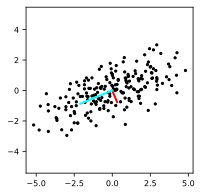

In [33]:
# Run and show output of the reference solution
exercise_eigen_pca()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCPT_License.png" width=100% style="float: right;" alt="PCPT License"></a>
</div>